In [1]:
from myutils import cache, clean_all_cache, plot

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

In [21]:
c = LoadEstimates(r'MLEtest(SIM)\nodelay\sin\di_3px_f0.25_d0.npz')
ff = lambda f: np.sum(np.sin(2*np.pi*f*np.arange(50)) * (c.time_domain[5] + 100))

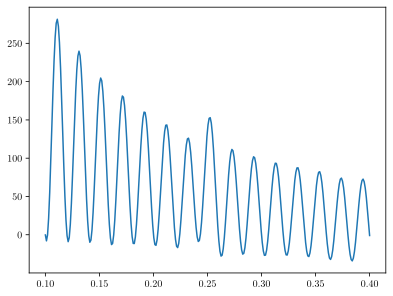

In [22]:
plot((0.1, 0.4), ff)

In [2]:
clean_all_cache()

done


In [3]:
@cache
def read_est(A):
    file_tree = [
        f'__estimates__/0noise/spade_{A}px/spade_{A}px_' + 'f{}_d0.npz',
        f'__estimates__/0noise/di_{A}px/di_{A}px_' + 'f{}_d0.npz'
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in np.linspace(0.1, 0.4, 61):
            c = LoadEstimates(file.format(np.round(f, 5))) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.mean())
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.mean())

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

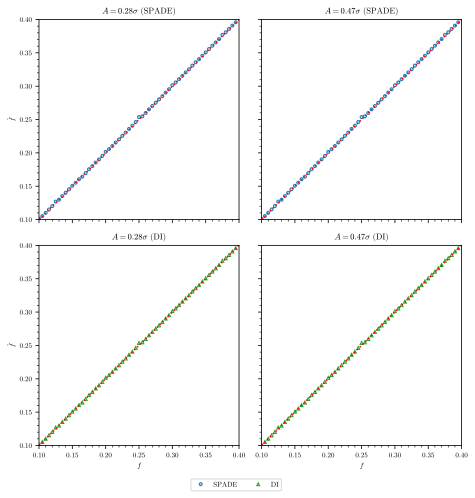

In [4]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 * 2 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(width, width), sharex=True, sharey=True)

for A in (3, 5):
    if A == 3:
        ax_spade = ax1
        ax_di = ax3

    else:
        ax_spade = ax2
        ax_di = ax4

    x_axis = np.linspace(0.1, 0.4, 1000)

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax_spade.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax_di.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))


from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2, ax3, ax4):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)
    ax.set_ylim(0.1, 0.4)

    ax.set_box_aspect(1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax3.set_xlabel(r'$f$')
ax4.set_xlabel(r'$f$')
ax1.set_ylabel(r'$\hat f$')
ax3.set_ylabel(r'$\hat f$')

ax1.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax2.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax3.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')
ax4.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')

for ax in (ax1, ax2, ax3, ax4):
    ax.plot([0.1, 0.4], [0.1, 0.4], 'r:')

fig.legend([line1, line2], ['SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
# plt.savefig('ideal.pdf')
plt.savefig('Mean.svg')
plt.show()

cache hit: reading result from cache file
cache hit: reading result from cache file


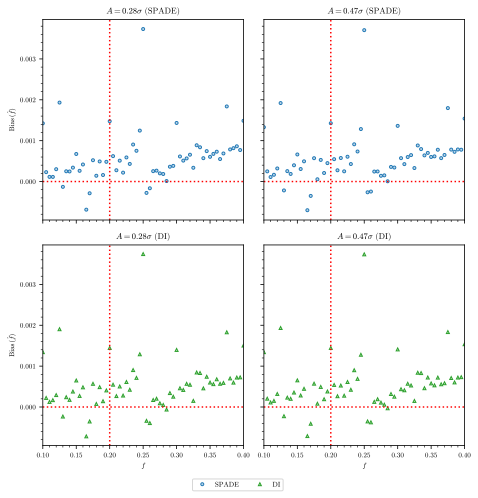

In [5]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 * 2 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(width, width), sharex=True, sharey=True)

for A in (3, 5):
    if A == 3:
        ax_spade = ax1
        ax_di = ax3

    else:
        ax_spade = ax2
        ax_di = ax4


    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax_spade.plot(spade_x, spade_y - spade_x, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax_di.plot(di_x, di_y - di_x,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))


from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2, ax3, ax4):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)
    # ax.set_ylim(0.1, 0.4)

    ax.set_box_aspect(1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax3.set_xlabel(r'$f$')
ax4.set_xlabel(r'$f$')
ax1.set_ylabel(r'${\rm Bias\,}(\hat f)$')
ax3.set_ylabel(r'${\rm Bias\,}(\hat f)$')

ax1.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax2.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax3.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')
ax4.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')

for ax in (ax1, ax2, ax3, ax4):
    ax.plot([0.1, 0.4], [0, 0], 'r:')
    ax.axvline(0.2, color = 'r', linestyle=':')

fig.legend([line1, line2], ['SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
# plt.savefig('ideal.pdf')
plt.savefig('Bias.svg')
plt.show()

cache hit: reading result from cache file
cache hit: reading result from cache file


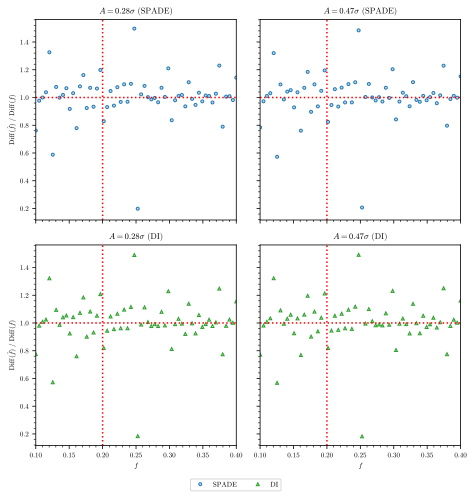

In [6]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 * 2 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(width, width), sharex=True, sharey=True)

for A in (3, 5):
    if A == 3:
        ax_spade = ax1
        ax_di = ax3

    else:
        ax_spade = ax2
        ax_di = ax4

    di_x, di_y, spade_x, spade_y = read_est(A)
    spade_bias = spade_y - spade_x
    di_bias = di_y - di_x

    
    line1, = ax_spade.plot(np.linspace(0.1, 0.4, 60), np.diff(spade_y) / np.diff(spade_x), 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax_di.plot(np.linspace(0.1, 0.4, 60), np.diff(di_y) / np.diff(di_x),
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))


from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2, ax3, ax4):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)
    # ax.set_ylim(0.1, 0.4)

    ax.set_box_aspect(1)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax3.set_xlabel(r'$f$')
ax4.set_xlabel(r'$f$')
ax1.set_ylabel(r'${\rm Diff\,}(\hat f)~/~{\rm Diff\,}(f) $')
ax3.set_ylabel(r'${\rm Diff\,}(\hat f)~/~{\rm Diff\,}(f) $')

ax1.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax2.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (SPADE)')
ax3.set_title(rf'$A = {np.round(3 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')
ax4.set_title(rf'$A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$ (DI)')

for ax in (ax1, ax2, ax3, ax4):
    ax.axhline(1, color = 'r', linestyle=':')
    ax.axvline(0.2, color = 'r', linestyle=':')
    # ax.set_ylim)

fig.legend([line1, line2], ['SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
# plt.savefig('ideal.pdf')
plt.savefig('Diff.svg')
plt.show()

In [7]:
c_spade = LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{0}.npz')
c_di = LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{0}.npz')

spade_pn = c_spade.photons.mean() - qCMOS.convert2photons(c_spade.background, 0).mean()
di_pn = c_di.photons.mean() - qCMOS.convert2photons(c_di.background, 0).mean()

spade_f = [(LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{d}.npz').estimates_a).mean() for d in np.arange(0, 101, 2)]
di_f = [(LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{d}.npz').estimates_a).mean() for d in np.arange(0, 101, 2)]

spade_b = [(LoadEstimates(rf'__estimates__/noisy/spade_5px/spade_5px_f0.2_d{d}.npz').background).mean() for d in np.arange(0, 101, 2)]
di_b = [(LoadEstimates(rf'__estimates__/noisy/di_5px/di_5px_f0.2_d{d}.npz').background).mean() for d in np.arange(0, 101, 2)]

spade_b = qCMOS.convert2photons(np.array(spade_b)) / spade_pn
di_b = qCMOS.convert2photons(np.array(di_b)) / di_pn

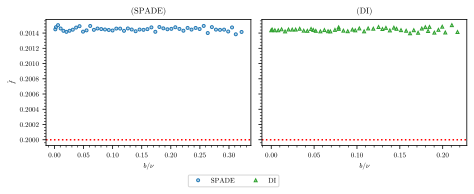

In [8]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 * 2 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(width, width * 0.5), sharex=False, sharey=True)


x_axis = np.linspace(0.1, 0.4, 1000)

line1, = ax1.plot(spade_b, spade_f, 
                marker='o', linestyle='', markersize=3,
                markeredgecolor=c1, markerfacecolor=(c1, 0.3))

line2, = ax2.plot(di_b, di_f,
                marker='^', linestyle='', markersize=3,
                markeredgecolor=c2, markerfacecolor=(c2, 0.3))


from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax1.set_ylabel(r'$\hat f$')

ax1.set_title(rf'(SPADE)')
ax2.set_title(rf'(DI)')

for ax in (ax1, ax2):
    ax.axhline(0.2, color='r', linestyle=':')
    ax.set_xlabel(r'$b/\nu$')

fig.legend([line1, line2], ['SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.05))
plt.tight_layout()
# plt.savefig('ideal.pdf')
plt.savefig('Mean_Noisy.svg')
plt.show()

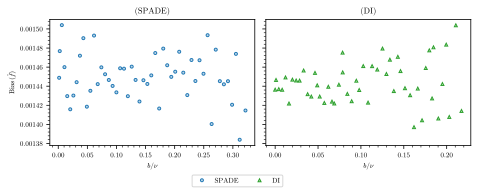

In [9]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 * 2 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(width, width * 0.5), sharex=False, sharey=True)


x_axis = np.linspace(0.1, 0.4, 1000)

line1, = ax1.plot(spade_b, np.array(spade_f) - 0.2, 
                marker='o', linestyle='', markersize=3,
                markeredgecolor=c1, markerfacecolor=(c1, 0.3))

line2, = ax2.plot(di_b, np.array(di_f) - 0.2,
                marker='^', linestyle='', markersize=3,
                markeredgecolor=c2, markerfacecolor=(c2, 0.3))


from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax1.set_ylabel(r'${\rm Bias\,}{(\hat f)}$')

ax1.set_title(rf'(SPADE)')
ax2.set_title(rf'(DI)')

for ax in (ax1, ax2):
    # ax.axhline(0, color='r', linestyle=':')
    ax.set_xlabel(r'$b/\nu$')

fig.legend([line1, line2], ['SPADE', 'DI'], ncol=2, loc='lower center', bbox_to_anchor=(0.5, 0.05))
plt.tight_layout()
# plt.savefig('ideal.pdf')
plt.savefig('Bias_Noisy.svg')
plt.show()